In [6]:
"""
Demonstration of the SOLID plant anatomy framework.

This script shows how to:
1. Create pine needle and root anatomies
2. Add and remove layers dynamically
3. Generate and visualize anatomical structures
4. Export data
"""

import matplotlib.pyplot as plt
from pine_needle_anatomy import PineNeedleAnatomy
from root_anatomy import RootAnatomy
from layer import Layer


In [7]:
"""Demonstrate root anatomy with layer management."""
print("=" * 60)
print("ROOT ANATOMY DEMONSTRATION")
print("=" * 60)

# Create a root anatomy instance
root = RootAnatomy(randomness=1.0, root_diameter=0.5)

print(f"\nInitial layers: {root.list_layers()}")
print(f"Number of layers: {len(root.layer_manager)}")

# Generate and plot the initial structure
print("\n1. Generating initial structure...")
fig = root.plot_layers(show=False)
plt.savefig('output/root_initial_layers.png', dpi=150, bbox_inches='tight')
print("   Saved: root_initial_layers.png")
plt.close()

# Generate cells
print("\n2. Generating cell structure (Voronoi tessellation)...")
fig = root.plot_cells(show=False)
plt.savefig('output/root_initial_cells.png', dpi=150, bbox_inches='tight')
print("   Saved: root_initial_cells.png")
plt.close()

# Get statistics
stats = root.get_statistics()
print("\n3. Anatomical statistics:")
print(f"   Total cells: {stats['total_cells']}")
print(f"   Cell types: {', '.join(stats['cell_types'])}")
print(f"   Total area: {stats['total_area']:.4f} mm²")

# Add exodermis layer
print("\n4. Adding 'exodermis' layer...")
exodermis = Layer(
    name="exodermis",
    cell_diameter=0.018,
    n_layers=1,
    order=4.5  # Between cortex (4) and epidermis (5)
)
root.add_layer(exodermis)
print(f"   Layers after addition: {root.list_layers()}")

fig = root.plot_cells(show=False)
plt.savefig('output/root_with_exodermis.png', dpi=150, bbox_inches='tight')
print("   Saved: root_with_exodermis.png")
plt.close()

# Modify cortex layer
print("\n5. Modifying cortex layer...")
cortex = root.get_layer("cortex")
root.remove_layer("cortex")

# Create new cortex with different properties
new_cortex = Layer(
    name="cortex",
    cell_diameter=0.06,  # Larger cells
    n_layers=3,          # Fewer layers
    order=4
)
root.add_layer(new_cortex)

fig = root.plot_cells(show=False)
plt.savefig('output/root_modified_cortex.png', dpi=150, bbox_inches='tight')
print("   Saved: root_modified_cortex.png")
plt.close()

# Export data
print("\n6. Exporting data...")
root.export_to_csv('output/root_cells.csv')
print("   Saved: root_cells.csv")

print("\nRoot anatomy demonstration complete!\n")

ROOT ANATOMY DEMONSTRATION

Initial layers: ['epidermis', 'cortex', 'endodermis', 'pericycle']
Number of layers: 4

1. Generating initial structure...
   Saved: root_initial_layers.png

2. Generating cell structure (Voronoi tessellation)...
   Saved: root_initial_cells.png

3. Anatomical statistics:
   Total cells: 3577
   Cell types: epidermis, cortex, endodermis, pericycle, vascular_parenchyma
   Total area: 0.2190 mm²

4. Adding 'exodermis' layer...
   Layers after addition: ['epidermis', 'cortex', 'endodermis', 'pericycle', 'exodermis']
   Saved: root_with_exodermis.png

5. Modifying cortex layer...
   Saved: root_modified_cortex.png

6. Exporting data...
   Saved: root_cells.csv

Root anatomy demonstration complete!



In [8]:
"""Demonstrate pine needle anatomy with layer management."""
print("=" * 60)
print("PINE NEEDLE ANATOMY DEMONSTRATION")
print("=" * 60)

# Create a pine needle anatomy instance
needle = PineNeedleAnatomy(randomness=1.0)

print(f"\nInitial layers: {needle.list_layers()}")
print(f"Number of layers: {len(needle.layer_manager)}")

# Generate and plot the initial structure
print("\n1. Generating initial structure...")
fig = needle.plot_layers(show=False)
plt.savefig('output/needle_initial_layers.png', dpi=150, bbox_inches='tight')
print("   Saved: needle_initial_layers.png")
plt.close()

# Generate cells
print("\n2. Generating cell structure (Voronoi tessellation)...")
fig = needle.plot_cells(show=False)
plt.savefig('output/needle_initial_cells.png', dpi=150, bbox_inches='tight')
print("   Saved: needle_initial_cells.png")
plt.close()

# Get statistics
stats = needle.get_statistics()
print("\n3. Anatomical statistics:")
print(f"   Total cells: {stats['total_cells']}")
print(f"   Cell types: {', '.join(stats['cell_types'])}")
print(f"   Total area: {stats['total_area']:.4f} mm²")
print(f"   Mean cell area: {stats['mean_cell_area']:.6f} mm²")

# Add a new layer
print("\n4. Adding a new 'sclerenchyma' layer...")
sclerenchyma = Layer(
    name="sclerenchyma",
    cell_diameter=0.02,
    n_layers=2,
    order=4.5  # Between mesophyll (4) and hypodermis (5)
)
needle.add_layer(sclerenchyma)
print(f"   Layers after addition: {needle.list_layers()}")

# Regenerate with new layer
fig = needle.plot_cells(show=False)
plt.savefig('output/needle_with_sclerenchyma.png', dpi=150, bbox_inches='tight')
print("   Saved: needle_with_sclerenchyma.png")
plt.close()

# Remove a layer
print("\n5. Removing 'hypodermis' layer...")
removed = needle.remove_layer("hypodermis")
print(f"   Removed: {removed}")
print(f"   Layers after removal: {needle.list_layers()}")

# Regenerate after removal
fig = needle.plot_cells(show=False)
plt.savefig('output/needle_without_hypodermis.png', dpi=150, bbox_inches='tight')
print("   Saved: needle_without_hypodermis.png")
plt.close()

# Modify central cylinder parameters
print("\n6. Modifying central cylinder parameters...")
needle.set_central_cylinder_params(
    transfusion_layers=5,
    cell_diameter=0.008
)
fig = needle.plot_cells(show=False)
plt.savefig('output/needle_modified_center.png', dpi=150, bbox_inches='tight')
print("   Saved: needle_modified_center.png")
plt.close()

# Export data
print("\n7. Exporting data...")
needle.export_to_csv('needle_cells.csv')
print("   Saved: needle_cells.csv")

print("\nPine needle demonstration complete!\n")

PINE NEEDLE ANATOMY DEMONSTRATION

Initial layers: ['epidermis', 'hypodermis', 'mesophyll', 'endodermis']
Number of layers: 4

1. Generating initial structure...
   Saved: needle_initial_layers.png

2. Generating cell structure (Voronoi tessellation)...
   Saved: needle_initial_cells.png

3. Anatomical statistics:
   Total cells: 2068
   Cell types: epidermis, hypodermis, mesophyll, endodermis, transfusion, parenchyma
   Total area: 0.2050 mm²
   Mean cell area: 0.000099 mm²

4. Adding a new 'sclerenchyma' layer...
   Layers after addition: ['epidermis', 'hypodermis', 'mesophyll', 'endodermis', 'sclerenchyma']
   Saved: needle_with_sclerenchyma.png

5. Removing 'hypodermis' layer...
   Removed: Layer(name='hypodermis', diameter=0.0250, n_layers=3, order=5)
   Layers after removal: ['epidermis', 'mesophyll', 'endodermis', 'sclerenchyma']
   Saved: needle_without_hypodermis.png

6. Modifying central cylinder parameters...
   Saved: needle_modified_center.png

7. Exporting data...
   Save

COMPARATIVE VISUALIZATION


<module 'matplotlib.pyplot' from 'c:\\Users\\Dilhan\\Documents\\Projects\\Python\\GRANAP\\granap\\Lib\\site-packages\\matplotlib\\pyplot.py'>

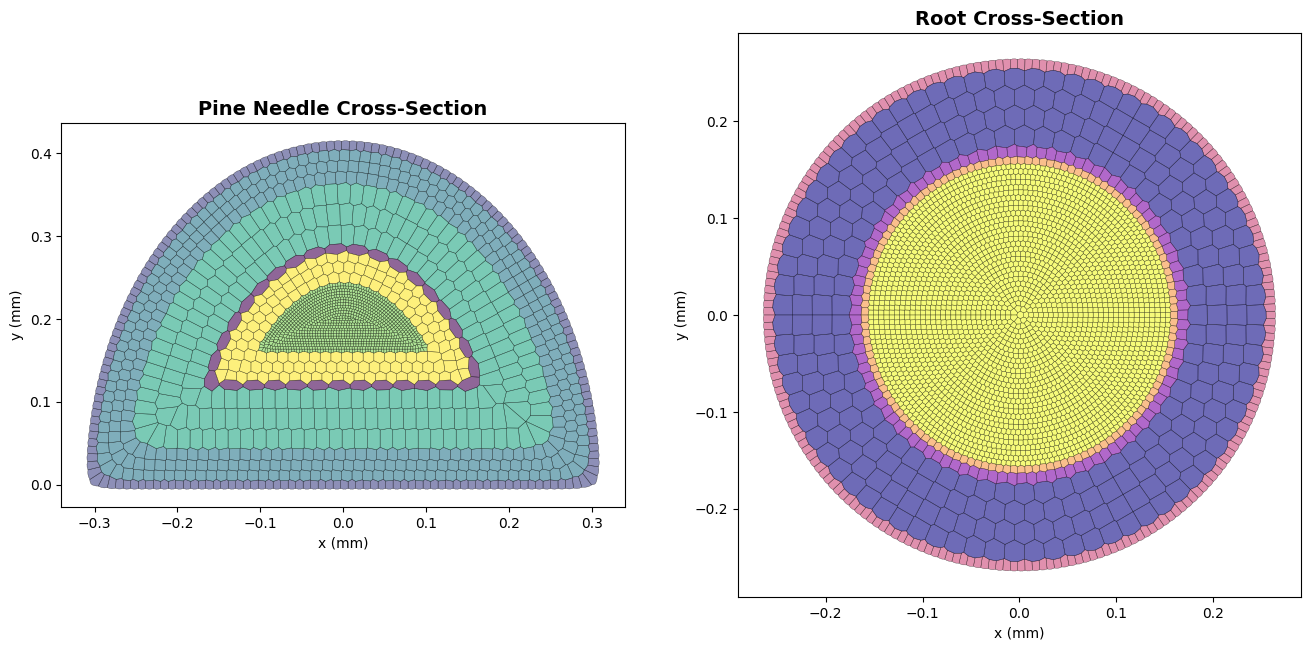

In [9]:
"""Create side-by-side comparison of both anatomy types."""
print("=" * 60)
print("COMPARATIVE VISUALIZATION")
print("=" * 60)

# Create both anatomies
needle = PineNeedleAnatomy()
root = RootAnatomy()

# Create comparison figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot needle
needle_cells = needle.generate_cells()
needle_cells.plot(
    ax=ax1,
    column='type',
    cmap='viridis',
    edgecolor='black',
    linewidth=0.3,
    alpha=0.6,
    legend=False
)
ax1.set_aspect('equal')
ax1.set_title('Pine Needle Cross-Section', fontsize=14, fontweight='bold')
ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')

# Plot root
root_cells = root.generate_cells()
root_cells.plot(
    ax=ax2,
    column='type',
    cmap='plasma',
    edgecolor='black',
    linewidth=0.3,
    alpha=0.6,
    legend=False
)
ax2.set_aspect('equal')
ax2.set_title('Root Cross-Section', fontsize=14, fontweight='bold')
ax2.set_xlabel('x (mm)')
ax2.set_ylabel('y (mm)')

plt
